In [1]:
import numpy as np
import matplotlib.pyplot as plt
import json_tricks


In [2]:
inputs = json_tricks.load('inputs/inputs.json')

answer = {
    f'case_{index}': {}
    for index, case in enumerate(inputs)
}


# Random Variables and Covariance

In the previous tasks, expectation and variance appeared as formulas. Here we will treat them as quantities that can be estimated from samples.

We will start with one discrete random variable, then move to two random variables and covariance, and finally to a data matrix. The main goal is to understand why a centered matrix product, `X_centered.T @ X_centered`, is the numerator of a covariance matrix.


# Task 1. Theoretical Mean and Variance

For a discrete random variable with possible values `values` and probabilities `probabilities`, implement the theoretical expectation and variance.

Implement the functions below:

- `expected_value(values, probabilities)` (theoretical average of the random values).
- `variance(values, probabilities)`.

Both functions should return a single number.

In [3]:
def expected_value(values, probabilities):
    result = sum(v * p for v, p in zip(values, probabilities))
    return result


def variance(values, probabilities):
    mean = expected_value(values, probabilities)
    result = sum(p * (v - mean) ** 2 for v, p in zip(values, probabilities))
    return result


# Check 1. Mean and Variance

Run this immediately after implementing `expected_value` and `variance`.


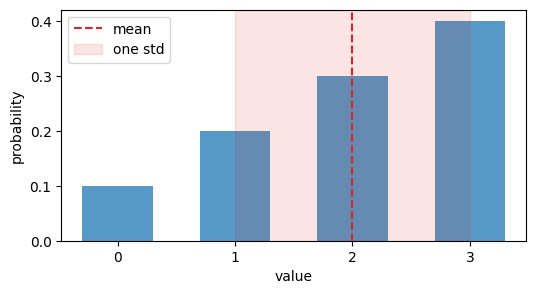

expected value: 2.0
variance: 1.0


In [4]:
values_check = np.array([0., 1., 2., 3.])
probabilities_check = np.array([0.1, 0.2, 0.3, 0.4])

mean_check = expected_value(values_check, probabilities_check)
variance_check = variance(values_check, probabilities_check)

np.testing.assert_allclose(mean_check, 2.0)
np.testing.assert_allclose(variance_check, 1.0)

plt.figure(figsize=(6, 3))
plt.bar(values_check, probabilities_check, width=0.6, alpha=0.75)
plt.axvline(mean_check, color='tab:red', linestyle='--', label='mean')
plt.axvspan(mean_check - np.sqrt(variance_check), mean_check + np.sqrt(variance_check), color='tab:red', alpha=0.12, label='one std')
plt.xticks(values_check)
plt.xlabel('value')
plt.ylabel('probability')
plt.legend()
plt.show()

print('expected value:', mean_check)
print('variance:', variance_check)

for index, case in enumerate(inputs):
    answer[f'case_{index}']['expected_value'] = expected_value(case['values'], case['probabilities'])
    answer[f'case_{index}']['variance'] = variance(case['values'], case['probabilities'])


# Task 2. Sampling and Empirical Estimates

Sampling turns the random variable into an array. From that array, estimate mean, variance, and the whole distribution.

Implement the functions below:

- `sample_random_variable(values, probabilities, n_samples, seed=42)`: use the seed to create a reproducible random generator and return `n_samples` draws from `values` with the given probabilities.
- `empirical_mean(samples)`: return the arithmetic mean of the sampled values.
- `empirical_variance(samples)`: return the empirical variance, using the average squared distance from the empirical mean.
- `empirical_distribution(samples, values)`: for each value in `values`, return the fraction of samples equal to that value.


In [ ]:
def sample_random_variable(values, probabilities, n_samples, seed=42):
    rng = np.random.default_rng(seed)
    return rng.choice(values, size=n_samples, p=probabilities)


def empirical_mean(samples):
    ## YOUR CODE HERE
    return 0


def empirical_variance(samples):
    ## YOUR CODE HERE
    return 0


def empirical_distribution(samples, values):
    ## YOUR CODE HERE
    return np.zeros_like(values, dtype=float)


# Check 2. Sampling and Empirical Estimates

The empirical estimates should be close to the theoretical ones for a large sample.


In [ ]:
values_check = np.array([0., 1., 2., 3.])
probabilities_check = np.array([0.1, 0.2, 0.3, 0.4])
samples_check = sample_random_variable(values_check, probabilities_check, 20_000, seed=7)
empirical_probs_check = empirical_distribution(samples_check, values_check)

np.testing.assert_equal(samples_check.shape, (20_000,))
np.testing.assert_allclose(empirical_mean(samples_check), expected_value(values_check, probabilities_check), atol=0.03)
np.testing.assert_allclose(empirical_variance(samples_check), variance(values_check, probabilities_check), atol=0.05)
np.testing.assert_allclose(empirical_probs_check.sum(), 1.0)
np.testing.assert_allclose(empirical_probs_check, probabilities_check, atol=0.02)

x = np.arange(len(values_check))
plt.figure(figsize=(6, 3))
plt.bar(x - 0.18, probabilities_check, width=0.36, label='theoretical')
plt.bar(x + 0.18, empirical_probs_check, width=0.36, label='empirical')
plt.xticks(x, values_check)
plt.xlabel('value')
plt.ylabel('probability')
plt.legend()
plt.show()

print('empirical mean:', empirical_mean(samples_check))
print('empirical variance:', empirical_variance(samples_check))

for index, case in enumerate(inputs):
    case_samples = sample_random_variable(case['values'], case['probabilities'], 2000, seed=123)
    answer[f'case_{index}']['sample_shape'] = np.array(sample_random_variable(case['values'], case['probabilities'], 17, seed=5).shape)
    answer[f'case_{index}']['sample_values'] = sample_random_variable(case['values'], case['probabilities'], 12, seed=9)
    answer[f'case_{index}']['empirical_mean'] = empirical_mean(case_samples)
    answer[f'case_{index}']['empirical_variance'] = empirical_variance(case_samples)
    answer[f'case_{index}']['empirical_distribution'] = empirical_distribution(case_samples, case['values'])


# Task 3. Theoretical Covariance

For two random variables, covariance measures whether they tend to move together:

$$\mathrm{cov}(X, Y) = \mathbb E[(X - \mathbb E[X])(Y - \mathbb E[Y])]$$

It can also be computed as:

$$\mathrm{cov}(X, Y) = \mathbb E[XY] - \mathbb E[X]\mathbb E[Y]$$

Implement `theoretical_covariance(x_values, y_values, joint_probs)`:

- Treat `joint_probs[i, j]` as $P(X=x_i, Y=y_j)$.
- Compute the marginal probabilities of `X` and `Y` from `joint_probs`.
- Compute $\mathbb E[X]$, $\mathbb E[Y]$, and $\mathbb E[XY]$.
- Return $\mathbb E[XY] - \mathbb E[X]\mathbb E[Y]$ as a single number.


In [ ]:
def theoretical_covariance(x_values, y_values, joint_probs):
    ## YOUR CODE HERE
    return 0


# Check 3. Theoretical Covariance

This heatmap shows the joint distribution used in the covariance check.


In [ ]:
x_values_check = np.array([0., 1., 2.])
y_values_check = np.array([-1., 0., 1.])
joint_probs_check = np.array([
    [0.10, 0.10, 0.05],
    [0.05, 0.25, 0.10],
    [0.00, 0.10, 0.25],
])

cov_check = theoretical_covariance(x_values_check, y_values_check, joint_probs_check)
np.testing.assert_allclose(joint_probs_check.sum(), 1.0)
np.testing.assert_allclose(cov_check, 0.275)

plt.figure(figsize=(5, 3.5))
plt.imshow(joint_probs_check, cmap='viridis')
plt.colorbar(label='probability')
plt.xticks(np.arange(len(y_values_check)), y_values_check)
plt.yticks(np.arange(len(x_values_check)), x_values_check)
plt.xlabel('Y value')
plt.ylabel('X value')
plt.title(f'cov(X, Y) = {cov_check:.4f}')
plt.show()

print('theoretical covariance:', cov_check)

for index, case in enumerate(inputs):
    answer[f'case_{index}']['theoretical_covariance'] = theoretical_covariance(case['x_values'], case['y_values'], case['joint_probs'])


# Task 4. Sampling Pairs and Empirical Covariance

Now sample pairs `(x, y)` from a joint distribution and estimate covariance from data.

Implement the functions below:

- `sample_joint_distribution(x_values, y_values, joint_probs, n_samples, seed=42)`: flatten the joint probabilities, sample index pairs reproducibly, and return two arrays: sampled `x` values and sampled `y` values.
- `empirical_covariance(x, y)`: return $\overline{(x_j - \bar x)(y_j - \bar y)}$


In [ ]:
def sample_joint_distribution(x_values, y_values, joint_probs, n_samples, seed=42):
    rng = np.random.default_rng(seed)
    flat_indices = rng.choice(joint_probs.size, size=n_samples, p=joint_probs.ravel())
    x_indices, y_indices = np.unravel_index(flat_indices, joint_probs.shape)
    return np.stack([x_values[x_indices], y_values[y_indices]], axis=1)


def empirical_covariance(x, y):
    ## YOUR CODE HERE
    return 0


# Check 4. Sampling Pairs and Empirical Covariance

The scatter plot shows sampled pairs. Larger samples should produce empirical covariance close to the theoretical value.


In [ ]:
pairs_check = sample_joint_distribution(x_values_check, y_values_check, joint_probs_check, 20_000, seed=13)
empirical_cov_check = empirical_covariance(pairs_check[:, 0], pairs_check[:, 1])

np.testing.assert_equal(pairs_check.shape, (20_000, 2))
np.testing.assert_allclose(empirical_cov_check, theoretical_covariance(x_values_check, y_values_check, joint_probs_check), atol=0.03)

plt.figure(figsize=(5, 3.5))
plt.scatter(pairs_check[:500, 0], pairs_check[:500, 1], alpha=0.25, s=18)
plt.xlabel('sampled X')
plt.ylabel('sampled Y')
plt.title(f'empirical cov = {empirical_cov_check:.4f}')
plt.show()

print('empirical covariance:', empirical_cov_check)

for index, case in enumerate(inputs):
    case_pairs = sample_joint_distribution(case['x_values'], case['y_values'], case['joint_probs'], 3000, seed=123)
    answer[f'case_{index}']['joint_sample_shape'] = np.array(case_pairs.shape)
    answer[f'case_{index}']['joint_sample_values'] = sample_joint_distribution(case['x_values'], case['y_values'], case['joint_probs'], 8, seed=11)
    answer[f'case_{index}']['empirical_covariance'] = empirical_covariance(case_pairs[:, 0], case_pairs[:, 1])


# Experiment. Sums of Independent Random Variables

For independent random variables, expectation is linear and variances add:

$$\mathbb E[X + Y] = \mathbb E[X] + \mathbb E[Y]$$

$$\mathbb V[X + Y] = \mathbb V[X] + \mathbb V[Y]$$


In [ ]:
x_values_ind = np.array([-1., 0., 2.])
y_values_ind = np.array([1., 3., 5.])
p_x_ind = np.array([0.25, 0.50, 0.25])
p_y_ind = np.array([0.20, 0.30, 0.50])
joint_independent = p_x_ind[:, None] * p_y_ind[None, :]

EX = expected_value(x_values_ind, p_x_ind)
EY = expected_value(y_values_ind, p_y_ind)
VX = variance(x_values_ind, p_x_ind)
VY = variance(y_values_ind, p_y_ind)

sum_values_grid = x_values_ind[:, None] + y_values_ind[None, :]
E_sum = np.sum(sum_values_grid * joint_independent)
V_sum = np.sum((sum_values_grid - E_sum) ** 2 * joint_independent)

np.testing.assert_allclose(E_sum, EX + EY)
np.testing.assert_allclose(V_sum, VX + VY)
np.testing.assert_allclose(theoretical_covariance(x_values_ind, y_values_ind, joint_independent), 0.0, atol=1e-12)

x_samples = sample_random_variable(x_values_ind, p_x_ind, 20_000, seed=101)
y_samples = sample_random_variable(y_values_ind, p_y_ind, 20_000, seed=202)
sum_samples = x_samples + y_samples

np.testing.assert_allclose(empirical_mean(sum_samples), EX + EY, atol=0.05)
np.testing.assert_allclose(empirical_variance(sum_samples), VX + VY, atol=0.08)

plt.figure(figsize=(6, 3))
plt.hist(sum_samples, bins=np.arange(sum_samples.min() - 0.5, sum_samples.max() + 1.5), density=True, alpha=0.75)
plt.axvline(EX + EY, color='tab:red', linestyle='--', label='E[X] + E[Y]')
plt.axvspan(EX + EY - np.sqrt(VX + VY), EX + EY + np.sqrt(VX + VY), color='tab:red', alpha=0.12, label='one std')
plt.xlabel('X + Y')
plt.ylabel('empirical probability')
plt.legend()
plt.show()

print('E[X + Y]:', E_sum)
print('E[X] + E[Y]:', EX + EY)
print('Var(X + Y):', V_sum)
print('Var(X) + Var(Y):', VX + VY)


# Task 5. Covariance Matrix

A data matrix usually has observations in rows and variables/features in columns.

If `X` is centered column-by-column, then entry `(j, k)` of `X.T @ X` is:

$\sum_i (x_{ij} - \bar{x}_j)(x_{ik} - \bar{x}_k)$

This is the numerator of the empirical covariance between feature `j` and feature `k`. Dividing by `n` gives the biased empirical covariance matrix, while dividing by `n - 1` gives the unbiased estimator.

Implement the functions below:

- `center_columns(X)`: subtract the mean of each column and return the centered matrix.
- `covariance_matrix_manual(X)`: compute the biased covariance matrix entry by entry with loops after centering the columns.
- `covariance_matrix_vectorized(X)`: compute the same biased covariance matrix with matrix multiplication, `X_centered.T @ X_centered / n`.
- `raw_gram_matrix(X)`: return the uncentered Gram matrix `X.T @ X`.

So `X.T @ X` is called covariance-like only after centering and scaling. Without centering, it is a Gram matrix of raw feature dot products.


In [ ]:
def center_columns(X):
    ## YOUR CODE HERE
    return np.zeros_like(X)


def covariance_matrix_manual(X):
    ## YOUR CODE HERE
    return np.zeros((X.shape[1], X.shape[1]))


def covariance_matrix_vectorized(X):
    ## YOUR CODE HERE
    return np.zeros((X.shape[1], X.shape[1]))


def raw_gram_matrix(X):
    ## YOUR CODE HERE
    return np.zeros((X.shape[1], X.shape[1]))


# Check 5. Covariance Matrix

The manual and vectorized covariance matrices should match NumPy's biased covariance matrix.


In [ ]:
X_check = np.array([
    [1.0, 2.0, 1.0],
    [2.0, 4.0, 0.0],
    [3.0, 6.0, 1.0],
    [4.0, 8.0, 0.0],
])

centered_check = center_columns(X_check)
manual_cov_check = covariance_matrix_manual(X_check)
vectorized_cov_check = covariance_matrix_vectorized(X_check)
numpy_cov_check = np.cov(X_check, rowvar=False, bias=True)
raw_gram_check = raw_gram_matrix(X_check)

np.testing.assert_allclose(centered_check.mean(axis=0), np.zeros(X_check.shape[1]))
np.testing.assert_allclose(manual_cov_check, numpy_cov_check)
np.testing.assert_allclose(vectorized_cov_check, numpy_cov_check)
np.testing.assert_allclose(raw_gram_check, X_check.T @ X_check)

fig, axes = plt.subplots(1, 2, figsize=(8, 3))
axes[0].imshow(raw_gram_check, cmap='magma')
axes[0].set_title('raw X.T @ X')
axes[1].imshow(vectorized_cov_check, cmap='magma')
axes[1].set_title('centered covariance')
for ax in axes:
    ax.set_xticks(range(X_check.shape[1]))
    ax.set_yticks(range(X_check.shape[1]))
plt.tight_layout()
plt.show()

print('manual covariance:')
print(manual_cov_check)
print('vectorized covariance:')
print(vectorized_cov_check)

for index, case in enumerate(inputs):
    answer[f'case_{index}']['centered'] = center_columns(case['X'])
    answer[f'case_{index}']['covariance_manual'] = covariance_matrix_manual(case['X'])
    answer[f'case_{index}']['covariance_vectorized'] = covariance_matrix_vectorized(case['X'])
    answer[f'case_{index}']['numpy_covariance'] = np.cov(case['X'], rowvar=False, bias=True)
    answer[f'case_{index}']['raw_gram_matrix'] = raw_gram_matrix(case['X'])


# Small Experiment

Run the next cell after solving the tasks. The estimates should approach the theoretical values as the number of samples grows.


In [ ]:
values = np.array([0., 1., 2., 3., 4.])
probabilities = np.array([0.05, 0.15, 0.30, 0.35, 0.15])

print('Theoretical mean:', expected_value(values, probabilities))
print('Theoretical variance:', variance(values, probabilities))

for n_samples in [10, 100, 1000, 10000]:
    samples = sample_random_variable(values, probabilities, n_samples, seed=7)
    print(n_samples, empirical_mean(samples), empirical_variance(samples))


# Covariance Matrix Demo

Here the columns of `X` are features. Notice that the diagonal of the covariance matrix contains feature variances, and the off-diagonal entries contain pairwise covariances.


In [ ]:
X_demo = np.array([
    [1.0, 2.0, 1.0],
    [2.0, 4.0, 0.0],
    [3.0, 6.0, 1.0],
    [4.0, 8.0, 0.0],
])

print(covariance_matrix_vectorized(X_demo))
print(np.cov(X_demo, rowvar=False, bias=True))


In [ ]:
json_tricks.dump(answer, '.answer.json')
